In [10]:
import numpy as np
import matplotlib.pyplot as plt

pts1 = '''300,519.19
305,529.96
312,518.32
325,504.75
335,475.34'''

305,663.95
pts2_1 = '''298,645.18
305,634.56
312.5,620.68
325,603.91
335,574.04'''

pts2_2 = '''298,624.05
305,608.38
312.5,589.58
325,560.95
335,529.85'''

5.846272655841808
5.57023011654144
4.960781531003124


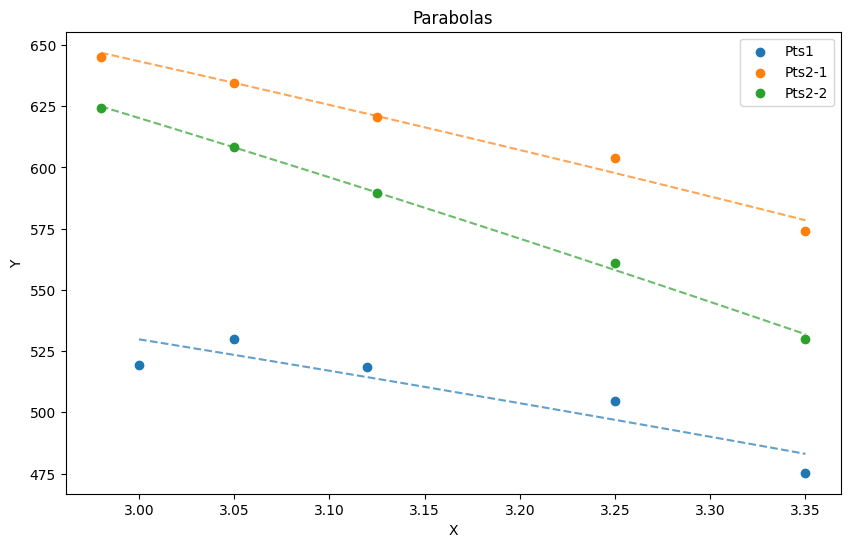

In [14]:
plt.figure(figsize=(10, 6))
for pts, label in zip([pts1, pts2_1, pts2_2], ['Pts1', 'Pts2-1', 'Pts2-2']):
    data = np.array([list(map(float, line.split(','))) for line in pts.splitlines()])
    x_data = data[:, 0] / 100
    y_data = data[:, 1]
    
    # Plot scatter points
    plt.scatter(x_data, y_data, label=label)
    
    # Fit parabola without linear term: y = a*x^2 + c
    A = np.column_stack([x_data**2, np.ones_like(x_data)])
    coeffs = np.linalg.lstsq(A, y_data, rcond=None)[0]
    
    # Plot parabolic fit
    x_fit = np.linspace(x_data.min(), x_data.max(), 100)
    y_fit = coeffs[0] * x_fit**2 + coeffs[1]
    plt.plot(x_fit, y_fit, '--', alpha=0.7)

    print(np.sqrt(-coeffs[1] / coeffs[0]))

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Parabolas')
plt.legend()
plt.show()

In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
import scienceplots
plt.style.use(['science'])

def import_files(t):
    if t != 3:
        return [f for f in os.listdir('data/csv/coils') if f.endswith(f'{t}.csv')]
    else:
        return [f for f in os.listdir('data/csv/coils')]

def plot(file, data):
    time = data[:, 0]
    outer_voltage = data[:, 1]
    inner_voltage = data[:, 3]
    inner_voltage = inner_voltage - np.mean(inner_voltage[-20:])  # Remove DC offset
    magnetisation = - np.cumsum(inner_voltage) * np.mean(np.diff(time))  # Simple integration for magnetization
    magnetic_field = (outer_voltage) * 600  #
    idx = magnetic_field > 0.99 * np.max(magnetic_field)
    p = np.polyfit(time[idx], magnetisation[idx], 1)
    magnetisation = magnetisation - (p[0]*time + p[1])
    plt.plot(magnetic_field, magnetisation, label='File: ' + file)
    plt.xlabel('Magnetic Field (Gauss)')
    plt.ylabel('Magnetization (emu)')
    plt.title('Magnetization vs Magnetic Field')
    plt.legend()
    plt.grid()
    plt.show()


def main():
    t = 1
    plt.figure()
    integrate = False
    filter = False
    files = import_files(t)
    files.sort()  # Sort files for consistent plotting order
    for file in files:
        with open(f'data/csv/coils/{file}', 'r') as f:
            data = np.loadtxt(f, delimiter=',', skiprows=1)
            #data = data[data[:, 1] > 10/600]  # Filter rows where outer voltage > 10
            if filter:
                max_outer_index = np.argmax(data[:, 1])
                data = data[:max_outer_index+1]
            data = data[data[:, 1] > 5/600]
            datamax = np.max(data[:, 1])
            #data = data[data[:, 1] < datamax - 5/600]  # Keep only data where outer voltage < 90% of its max
            if integrate:
                #data[:, 3] = data[:, 3] - np.mean(data[:, 3][data[:, 1] > datamax - 20/600])  # Remove DC offset using points where outer voltage > 10
                data[:, 3] = - np.cumsum(data[:, 3]) * np.mean(np.diff(data[:, 0]))  # Integrate inner voltage to get magnetization
            plot(file, data)
    plt.xlabel('Magnetic Field (Gauss)')
    plt.ylabel('Magnetization (emu)')
    plt.title('Magnetization vs Magnetic Field')
    plt.legend()
    plt.grid()
    plt.show()

if __name__ == "__main__":    main()

FileNotFoundError: [Errno 2] No such file or directory: 'data/csv/coils'

<Figure size 350x262.5 with 0 Axes>